# NB08: 배달 수요 핫스팟 — Baseline Layer (Step 1)

**목적**: 카드매출 수요 + 유동인구 밀집도를 H3 헥사곤 그리드 위에 결합하여 "배송 시급도 지수" 생성

**입력**:
- `processed/card_delivery_demand.parquet` (NB04: 동별 배달수요지수)
- `processed/flow_pop_agg.parquet` (NB05: 동별 유동인구지수)
- `processed/seongnam_boundary.gpkg` (NB01: 행정동 경계)
- `processed/admin_code_crosswalk.csv`

**출력**: `processed/delivery_urgency_grid.gpkg` (H3 hex grid + urgency score per cell)

In [4]:
import pandas as pd
import geopandas as gpd
import numpy as np
import h3
from shapely.geometry import Polygon
from pathlib import Path

BASE = Path(r"E:\서울시데이터경진대회\Aero-Logic-Seoul")
OUT = BASE / "processed"

# 입력 데이터 로드
demand = pd.read_parquet(OUT / "card_delivery_demand_h3.parquet")
flow_pop = pd.read_parquet(OUT / "flow_pop_agg.parquet")
crosswalk = pd.read_csv(OUT / "admin_code_crosswalk.csv")
seoul = gpd.read_file(OUT / "seoul_boundary.gpkg", layer="dong")

# 행정동 코드 타입을 통일 (문자열)
seoul["CSV_ADMI_CD"] = pd.to_numeric(seoul["CSV_ADMI_CD"], errors="coerce").astype("Int64").astype(str)
demand["admi_cty_no"] = pd.to_numeric(demand["admi_cty_no"], errors="coerce").astype("Int64").astype(str)
flow_pop["CSV_ADMI_CD"] = pd.to_numeric(flow_pop["CSV_ADMI_CD"], errors="coerce").astype("Int64").astype(str)
crosswalk["CSV_ADMI_CD"] = pd.to_numeric(crosswalk["CSV_ADMI_CD"], errors="coerce").astype("Int64").astype(str)
crosswalk["SHP_ADM_CD"] = pd.to_numeric(crosswalk["SHP_ADM_CD"], errors="coerce").astype("Int64").astype(str)

# demand 데이터는 SHP_ADM_CD를 사용하므로 crosswalk를 통해 CSV_ADMI_CD를 병합해 줍니다
demand = demand.merge(crosswalk[["SHP_ADM_CD", "CSV_ADMI_CD"]], left_on="admi_cty_no", right_on="SHP_ADM_CD", how="left")

if "CSV_ADMI_CD" not in demand.columns:   
    demand = demand.merge(crosswalk[["SHP_ADM_CD", "CSV_ADMI_CD"]], left_on="admi_cty_no", right_on="SHP_ADM_CD", how="left")
print(f"카드 배달수요: {len(demand)} H3 cells") # [수정] 출력 문구 변경 (dongs -> H3 cells)
print(f"유동인구: {len(flow_pop)} dongs")
print(f"행정동 경계: {len(seoul)} dongs")

카드 배달수요: 6229 H3 cells
유동인구: 414 dongs
행정동 경계: 426 dongs


## 1. H3 헥사곤 그리드 생성

H3 Resolution 9 ≈ 한 변 ~174m, 면적 ~0.1 km² → 성남시 전역에 약 1,500~2,000개 셀.  
Resolution 8 ≈ 한 변 ~461m, 면적 ~0.74 km² → 약 200~300개 셀.  
**Resolution 9**를 사용하여 충분한 공간 해상도 확보.

In [5]:
H3_RES = 9

def h3_cell_to_polygon(h3_index):
    """H3 셀 인덱스를 Shapely Polygon으로 변환"""
    boundary = h3.cell_to_boundary(h3_index)
    # h3 v4는 (lat, lng) 순서로 반환 → Polygon은 (lng, lat) 필요
    return Polygon([(lng, lat) for lat, lng in boundary])

# 서울시 경계 내 H3 셀 생성
city = seoul.dissolve()
city_geojson = city.geometry.iloc[0].__geo_interface__

# geo_to_cells: GeoJSON dict → H3 셀 (h3 v4.4+)
h3_cells = list(h3.geo_to_cells(city_geojson, H3_RES))
print(f"H3 Resolution {H3_RES}: {len(h3_cells)} 셀 생성")

# GeoDataFrame으로 변환
hex_geoms = [h3_cell_to_polygon(h) for h in h3_cells]
hex_centers = [h3.cell_to_latlng(h) for h in h3_cells]

gdf_hex = gpd.GeoDataFrame(
    {
        "h3_index": h3_cells,
        "lat": [c[0] for c in hex_centers],
        "lon": [c[1] for c in hex_centers],
    },
    geometry=hex_geoms,
    crs="EPSG:4326",
)
print(f"그리드 생성 완료: {len(gdf_hex)} hexagons")
gdf_hex.head()

H3 Resolution 9: 8322 셀 생성
그리드 생성 완료: 8322 hexagons


,h3_index,lat,lon,geometry
0,8930e1daa3bffff,37.580684,126.967019,"POLYGON ((126.96875 37.58047, 126.968 37.58199..."
1,8930e1c336bffff,37.582947,127.040618,"POLYGON ((127.04235 37.58273, 127.0416 37.5842..."
2,8930e1caed3ffff,37.509726,127.055496,"POLYGON ((127.05723 37.50951, 127.05648 37.511..."
3,8930e1da8b3ffff,37.609563,126.964149,"POLYGON ((126.96588 37.60935, 126.96513 37.610..."
4,8930e0a5ac7ffff,37.575666,126.846237,"POLYGON ((126.84796 37.57545, 126.84721 37.576..."


## 2. 각 H3 셀에 행정동 매핑 → 동별 지표 할당

각 헥사곤 중심점이 어느 행정동에 속하는지 spatial join으로 결정

In [6]:
# 헥사곤 중심점 → 행정동 spatial join
hex_centers_gdf = gpd.GeoDataFrame(
    gdf_hex[["h3_index"]],
    geometry=gpd.points_from_xy(gdf_hex["lon"], gdf_hex["lat"]),
    crs="EPSG:4326",
)

hex_dong = gpd.sjoin(hex_centers_gdf, seoul[["CSV_ADMI_CD", "ADM_NM", "GU_NM", "geometry"]],
                     predicate="within", how="left")
hex_dong = hex_dong.drop_duplicates(subset=["h3_index"])
hex_dong = hex_dong.drop(columns=["geometry", "index_right"])

existing_cols = ["CSV_ADMI_CD", "ADM_NM", "GU_NM", "delivery_demand_index", "flow_pop_index"]
gdf_hex = gdf_hex.drop(columns=[c for c in existing_cols if c in gdf_hex.columns])

# gdf_hex에 동 정보 병합
gdf_hex = gdf_hex.merge(hex_dong[["h3_index", "CSV_ADMI_CD", "ADM_NM", "GU_NM"]], on="h3_index", how="left")

# 카드매출 배달수요 병합
gdf_hex = gdf_hex.merge(
    demand[["h3_index", "delivery_demand_index"]],
    on="h3_index", how="left",
)

# 유동인구 지수 병합
gdf_hex = gdf_hex.merge(
    flow_pop[["CSV_ADMI_CD", "flow_pop_index"]],
    on="CSV_ADMI_CD", how="left",
)

print(f"병합 결과: {len(gdf_hex)} hexagons")
print(f"배달수요 null: {gdf_hex['delivery_demand_index'].isna().sum()}")
print(f"유동인구 null: {gdf_hex['flow_pop_index'].isna().sum()}")

병합 결과: 9807 hexagons
배달수요 null: 3598
유동인구 null: 252


## 3. 배송 시급도 지수 산출

`urgency = 0.5 * delivery_demand + 0.3 * flow_pop + 0.2 * time_factor`  
(time_factor는 저녁 시간대 수요 비율 — NB04에서 이미 demand에 반영됨, 여기선 0.2를 demand에 추가 가중)

In [7]:
# null은 0으로 채움 (경계 밖 헥사곤)
gdf_hex["delivery_demand_index"] = gdf_hex["delivery_demand_index"].fillna(0)
gdf_hex["flow_pop_index"] = gdf_hex["flow_pop_index"].fillna(0)

# 종합 배송 시급도 지수
gdf_hex["urgency"] = (
    0.6 * gdf_hex["delivery_demand_index"]
    + 0.4 * gdf_hex["flow_pop_index"]
)

print(f"배송 시급도 지수 통계:")
print(gdf_hex["urgency"].describe())
print(f"\n상위 10 셀:")
top = gdf_hex.nlargest(10, "urgency")
print(top[["h3_index", "ADM_NM", "urgency", "delivery_demand_index", "flow_pop_index"]])

배송 시급도 지수 통계:
count    9807.000000
mean        0.099754
std         0.076166
min         0.000000
25%         0.049622
50%         0.080400
75%         0.129049
max         0.950430
Name: urgency, dtype: float64

상위 10 셀:
             h3_index       ADM_NM   urgency  delivery_demand_index  \
2682  8930e1d919bffff          여의동  0.950430               0.976386   
9804  8930e1d9517ffff          여의동  0.801832               0.728723   
3175  8930e1ca2bbffff         역삼1동  0.701280               0.502134   
3332  8930e1d9567ffff          여의동  0.695935               0.552227   
5549  8930e1d8dcbffff  종로1·2·3·4가동  0.666144               0.739896   
8229  8930e1ca207ffff         역삼1동  0.663420               0.439034   
2912  8930e1ca04bffff         역삼1동  0.658688               0.431147   
1661  8930e1ca3d3ffff         역삼1동  0.649223               0.415372   
4478  8930e1ca2abffff         역삼1동  0.631871               0.386451   
894   8930e1d808bffff          신촌동  0.630631               0.690529 

## 4. 시각화 + 저장

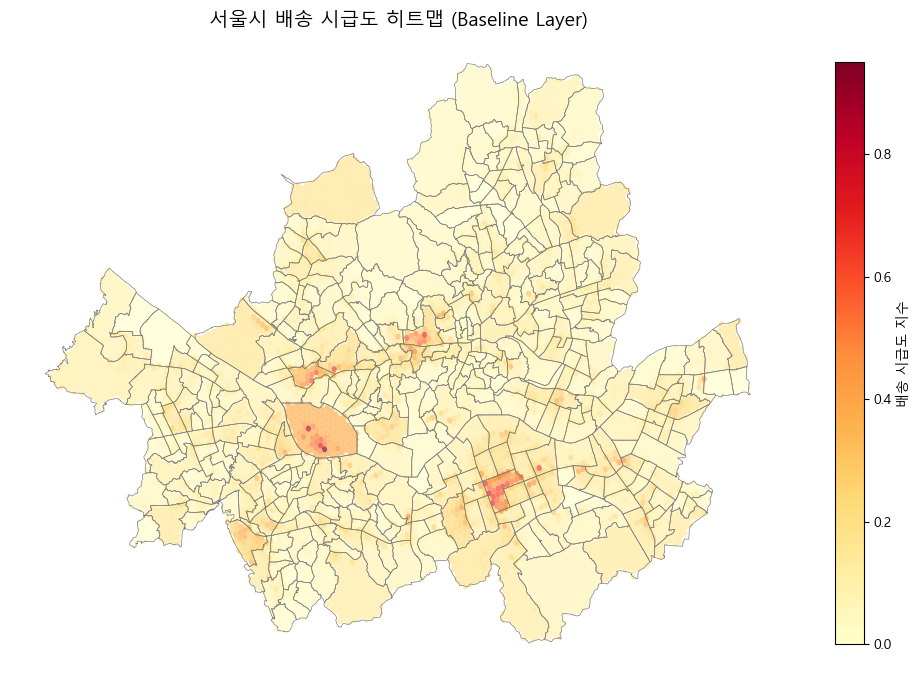

In [8]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# 행정동 경계
seoul.boundary.plot(ax=ax, color="gray", linewidth=0.5)

# 히트맵
gdf_hex.plot(
    ax=ax, column="urgency", cmap="YlOrRd", legend=True,
    alpha=0.7, edgecolor="none",
    legend_kwds={"label": "배송 시급도 지수", "shrink": 0.6},
)

ax.set_title("서울시 배송 시급도 히트맵 (Baseline Layer)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [11]:
# 저장
gdf_hex.to_file(OUT / "delivery_urgency_grid.gpkg", driver="GPKG")
print(f"저장 완료: {OUT / 'delivery_urgency_grid.gpkg'} ({len(gdf_hex)} hexagons)")

저장 완료: E:\서울시데이터경진대회\Aero-Logic-Seoul\processed\delivery_urgency_grid.gpkg (8322 hexagons)
